<a href="https://colab.research.google.com/github/Robinadev/Apple-webiste-cloning-with-React/blob/main/Fruit_Recognition_Model_Using_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Download Fruits 360 dataset
!kaggle datasets download -d moltean/fruits

# Unzip the dataset
!unzip fruits.zip -d /content/fruits


Streaming output truncated to the last 5000 lines.
  inflating: /content/fruits/fruits-360_dataset_original-size/fruits-360-original-size/Training/apple_red_yellow_1/r0_96.jpg  
  inflating: /content/fruits/fruits-360_dataset_original-size/fruits-360-original-size/Training/apple_red_yellow_1/r0_98.jpg  
  inflating: /content/fruits/fruits-360_dataset_original-size/fruits-360-original-size/Training/apple_red_yellow_1/r1_0.jpg  
  inflating: /content/fruits/fruits-360_dataset_original-size/fruits-360-original-size/Training/apple_red_yellow_1/r1_10.jpg  
  inflating: /content/fruits/fruits-360_dataset_original-size/fruits-360-original-size/Training/apple_red_yellow_1/r1_100.jpg  
  inflating: /content/fruits/fruits-360_dataset_original-size/fruits-360-original-size/Training/apple_red_yellow_1/r1_102.jpg  
  inflating: /content/fruits/fruits-360_dataset_original-size/fruits-360-original-size/Training/apple_red_yellow_1/r1_104.jpg  
  inflating: /content/fruits/fruits-360_dataset_original-s

In [3]:
# Install Kaggle package
!pip install -q kaggle

# Create a directory for Kaggle
!mkdir ~/.kaggle

# Copy the kaggle.json file into the directory
!cp kaggle.json ~/.kaggle/

# Set permissions
!chmod 600 ~/.kaggle/kaggle.json


In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define paths
train_dir = "/content/fruits-360_dataset_100x100/fruits-360/Training"
test_dir = "/content/fruits-360_dataset_100x100/fruits-360/Test"

# Image dimensions and batch size
IMG_SIZE = (100, 100)
BATCH_SIZE = 32

# Data generators
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)


FileNotFoundError: [Errno 2] No such file or directory: '/content/fruits-360_dataset_100x100/fruits-360/Training'

In [8]:
# Check extracted folder structure
!ls /content/fruits
!ls /content/fruits/fruits-360


fruits-360_dataset_100x100  fruits-360_dataset_original-size
ls: cannot access '/content/fruits/fruits-360': No such file or directory


In [9]:
import os

# List files in the content directory
print(os.listdir('/content'))


['.config', 'fruits', 'fruits.zip', 'kaggle.json', 'sample_data']


In [10]:
import zipfile

# Define the path to the uploaded ZIP file
zip_path = "/content/fruits.zip"

# Extract it to /content/fruits
extract_dir = "/content/fruits"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Dataset extracted successfully.")


Dataset extracted successfully.


In [17]:
# Check the extracted folder structure
print(os.listdir('/content/fruits/fruits-360_dataset_original-size/fruits-360-original-size'))
  # Check for Training and Test folders


['Papers', 'Training', 'Test', 'Meta', 'readme.md', 'Validation']


In [18]:
train_dir = "/content/fruits/fruits-360_dataset_original-size/fruits-360-original-size/Training"
test_dir = "/content/fruits/fruits-360_dataset_original-size/fruits-360-original-size/Test"
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image parameters
IMG_SIZE = (100, 100)
BATCH_SIZE = 32

# Data augmentation and rescaling
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Load training data
train_data = train_datagen.flow_from_directory(
    directory=train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# Load validation data
val_data = train_datagen.flow_from_directory(
    directory=train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)


Found 4993 images belonging to 24 classes.
Found 1238 images belonging to 24 classes.


In [19]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(100, 100, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(train_data.class_indices), activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
EPOCHS = 10
model.fit(train_data, validation_data=val_data, epochs=EPOCHS)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


157/157 ━━━━━━━━━━━━━━━━━━━━ 106s 649ms/step - accuracy: 0.3187 - loss: 2.4600 - val_accuracy: 0.9023 - val_loss: 0.4828
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 143s 656ms/step - accuracy: 0.8436 - loss: 0.4572 - val_accuracy: 0.8263 - val_loss: 0.6177
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 141s 654ms/step - accuracy: 0.7988 - loss: 0.6064 - val_accuracy: 0.9233 - val_loss: 0.3519
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 136s 616ms/step - accuracy: 0.9237 - loss: 0.2192 - val_accuracy: 0.9370 - val_loss: 0.3185
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 135s 572ms/step - accuracy: 0.9466 - loss: 0.1495 - val_accuracy: 0.9208 - val_loss: 0.2877
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 143s 576ms/step - accuracy: 0.9529 - loss: 0.1231 - val_accuracy: 0.9362 - val_loss: 0.3722
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 142s 581ms/step - accuracy: 0.9433 - loss: 0.1499 - val_accuracy: 0.9451 - val_loss: 0.3040
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 92s 583ms/step - accuracy: 0.9594 - loss: 0.118

In [20]:
# Save the model as an HDF5 file
model.save("fruit_recognition_model.h5")


In [21]:
from google.colab import files

# Download the model to your local computer
files.download("fruit_recognition_model.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

loss, accuracy = model.evaluate(test_data)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Found 3110 images belonging to 24 classes.
98/98 ━━━━━━━━━━━━━━━━━━━━ 21s 211ms/step - accuracy: 0.9913 - loss: 0.0478
Test Accuracy: 98.87%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


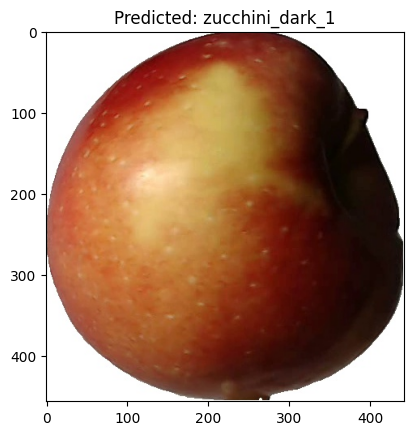

In [36]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def predict_image(image_path):
    # Read the image
    img = cv2.imread(image_path)

    # Resize the image to the desired size
    img = cv2.resize(img, (100, 100))

    # Normalize the image
    img = img / 255.0

    # Expand dimensions to match the model's input shape (batch size, height, width, channels)
    img = np.expand_dims(img, axis=0)

    # Make a prediction
    prediction = model.predict(img)

    # Get the predicted class index
    class_index = np.argmax(prediction)

    # Get the class label from the class indices
    class_label = list(train_data.class_indices.keys())[class_index]

    # Display the image with the predicted label
    plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
    plt.title(f"Predicted: {class_label}")
    plt.show()

# Example usage
predict_image("/content/fruits/fruits-360_dataset_original-size/fruits-360-original-size/Validation/apple_braeburn_1/r1_85.jpg")


In [35]:

print(os.listdir('/content/fruits/fruits-360_dataset_original-size/fruits-360-original-size/Validation/apple_braeburn_1/r1_85.jpg'))

NotADirectoryError: [Errno 20] Not a directory: '/content/fruits/fruits-360_dataset_original-size/fruits-360-original-size/Validation/apple_braeburn_1/r1_85.jpg'